In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple Silicon GPU
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


Using device: mps


In [6]:
data_dir = "/Users/felixkevinsinght/TN/PlantDiseasesDataset"

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Utility function to collect train/valid folders
def collect_dataset_paths(root):
    train_paths = []
    valid_paths = []
    for crop in os.listdir(root):
        crop_path = os.path.join(root, crop)
        if not os.path.isdir(crop_path):
            continue
        train_path = os.path.join(crop_path, "train")
        valid_path = os.path.join(crop_path, "valid")
        if os.path.isdir(train_path):
            train_paths.append(train_path)
        if os.path.isdir(valid_path):
            valid_paths.append(valid_path)
    return train_paths, valid_paths

# Aggregate all datasets
train_paths, valid_paths = collect_dataset_paths(data_dir)

# Merge all subfolder datasets into one
def load_combined_dataset(paths, transform):
    datasets_list = [datasets.ImageFolder(path, transform=transform) for path in paths]
    combined = torch.utils.data.ConcatDataset(datasets_list)
    return combined

train_dataset = load_combined_dataset(train_paths, transform)
val_dataset = load_combined_dataset(valid_paths, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Automatically get all classes
all_classes = set()
for path in train_paths:
    all_classes.update(os.listdir(path))
class_names = sorted(list(all_classes))
num_classes = len(class_names)
print("Detected classes:", class_names)
print("Total classes:", num_classes)


Detected classes: ['.DS_Store', 'Apple Black rot', 'Apple Healthy', 'Apple Scab', 'Bell pepper Bacterial spot', 'Bell pepper Healthy', 'Cedar apple rust', 'Cherry Healthy', 'Cherry Powdery mildew', 'Citrus Black spot', 'Citrus Healthy', 'Citrus canker', 'Citrus greening', 'Corn Common rust', 'Corn Gray leaf spot', 'Corn Healthy', 'Corn Northern Leaf Blight', 'Grape Black Measles', 'Grape Black rot', 'Grape Healthy', 'Grape Isariopsis Leaf Spot', 'Peach Bacterial spot', 'Peach Healthy', 'Potato Early blight', 'Potato Healthy', 'Potato Late blight', 'Strawberry Healthy', 'Strawberry Leaf scorch', 'Tomato Bacterial spot', 'Tomato Early blight', 'Tomato Healthy', 'Tomato Late blight', 'Tomato Leaf Mold', 'Tomato Mosaic virus', 'Tomato Septoria leaf spot', 'Tomato Spider mites', 'Tomato Target Spot', 'Tomato Yellow Leaf Curl Virus']
Total classes: 38


In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes).to(device)


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)


In [9]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=20):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_model_wts = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} Val Loss: {epoch_val_loss:.4f}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = model.state_dict()

    if best_model_wts:
        model.load_state_dict(best_model_wts)
    return train_losses, val_losses


In [10]:
train_losses, val_losses = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=20)


Epoch 1/20 - Train Loss: 1.0396 Val Loss: 2.3184
Epoch 2/20 - Train Loss: 0.5940 Val Loss: 2.1116
Epoch 3/20 - Train Loss: 0.4441 Val Loss: 2.2737
Epoch 4/20 - Train Loss: 0.3516 Val Loss: 2.4226
Epoch 5/20 - Train Loss: 0.3016 Val Loss: 2.7890
Epoch 6/20 - Train Loss: 0.2651 Val Loss: 2.6480
Epoch 7/20 - Train Loss: 0.1811 Val Loss: 2.8929
Epoch 8/20 - Train Loss: 0.1557 Val Loss: 2.8271
Epoch 9/20 - Train Loss: 0.1436 Val Loss: 3.5496
Epoch 10/20 - Train Loss: 0.1317 Val Loss: 3.2095
Epoch 11/20 - Train Loss: 0.1021 Val Loss: 3.4704
Epoch 12/20 - Train Loss: 0.0924 Val Loss: 4.1651
Epoch 13/20 - Train Loss: 0.0881 Val Loss: 4.5772
Epoch 14/20 - Train Loss: 0.0846 Val Loss: 4.3551
Epoch 15/20 - Train Loss: 0.0713 Val Loss: 4.7136
Epoch 16/20 - Train Loss: 0.0684 Val Loss: 4.7880
Epoch 17/20 - Train Loss: 0.0657 Val Loss: 4.9836
Epoch 18/20 - Train Loss: 0.0622 Val Loss: 5.0447
Epoch 19/20 - Train Loss: 0.0579 Val Loss: 5.3368
Epoch 20/20 - Train Loss: 0.0570 Val Loss: 5.3668


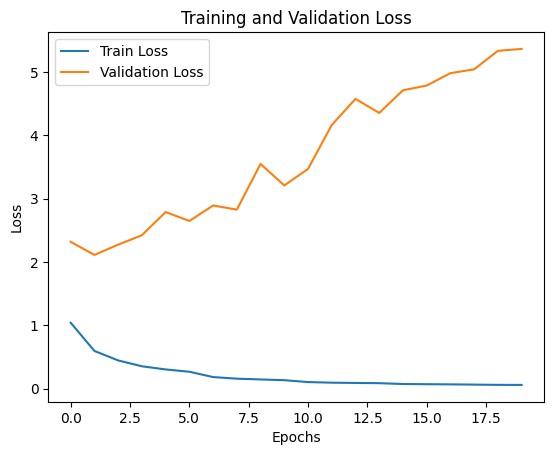

In [11]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [12]:
def accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

train_acc = accuracy(train_loader)
val_acc = accuracy(val_loader)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")


Train Accuracy: 0.9972
Validation Accuracy: 0.4381


In [13]:
torch.save(model.state_dict(), "plant_disease_model_m3.pt")


In [14]:
# Ensure you have this from the earlier step
print("Classes:", class_names)


Classes: ['.DS_Store', 'Apple Black rot', 'Apple Healthy', 'Apple Scab', 'Bell pepper Bacterial spot', 'Bell pepper Healthy', 'Cedar apple rust', 'Cherry Healthy', 'Cherry Powdery mildew', 'Citrus Black spot', 'Citrus Healthy', 'Citrus canker', 'Citrus greening', 'Corn Common rust', 'Corn Gray leaf spot', 'Corn Healthy', 'Corn Northern Leaf Blight', 'Grape Black Measles', 'Grape Black rot', 'Grape Healthy', 'Grape Isariopsis Leaf Spot', 'Peach Bacterial spot', 'Peach Healthy', 'Potato Early blight', 'Potato Healthy', 'Potato Late blight', 'Strawberry Healthy', 'Strawberry Leaf scorch', 'Tomato Bacterial spot', 'Tomato Early blight', 'Tomato Healthy', 'Tomato Late blight', 'Tomato Leaf Mold', 'Tomato Mosaic virus', 'Tomato Septoria leaf spot', 'Tomato Spider mites', 'Tomato Target Spot', 'Tomato Yellow Leaf Curl Virus']


In [15]:
from torchvision.transforms.functional import to_pil_image
from PIL import Image

def predict_image(image_path):
    # Load and preprocess the image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Ensure model is in eval mode
    model.eval()
    
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted_class = torch.max(output, 1)
        predicted_class = predicted_class.item()
    
    predicted_label = class_names[predicted_class]
    
    # Display result
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_label}")
    plt.axis('off')
    plt.show()

    return predicted_label


In [16]:
model.load_state_dict(torch.load("plant_disease_model_m3.pt", map_location=device))
model.to(device)
model.eval()


CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=38, bias=True)
  )
)

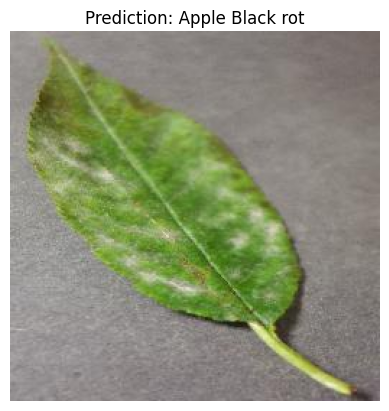

Predicted Class: Apple Black rot


In [20]:
image_path = "/Users/felixkevinsinght/TN/PlantDiseasesDataset/Cherry/train/Cherry Powdery mildew/CherryPowderyMildew(1).JPG"
predicted_label = predict_image(image_path)
print("Predicted Class:", predicted_label)
